In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import torch
import UniDISA
rna = sc.read_h5ad("../Dataset/Muto-2021/Muto-2021-RNA.h5ad")
atac_gas = sc.read_h5ad("../Dataset/Muto-2021/Muto-2021-FRAGS2RNA.h5ad")
atac_peak = sc.read_h5ad("../Dataset/Muto-2021/Muto-2021-ATAC.h5ad")

# Set figure size for all subsequent plots
sc.settings.set_figure_params(dpi=100, figsize=(4, 4))

Preprocess data

In [2]:
# Take intersection of genes
cm_genes = sorted(list(set(atac_gas.var_names) & set(rna.var_names)))
rna = rna[:, cm_genes]
atac_gas = atac_gas[:, cm_genes]

# Calculate highly variable genes
sc.pp.highly_variable_genes(rna, flavor='seurat_v3', n_top_genes=2000)
# sc.pp.highly_variable_genes(atac_gas, flavor='seurat_v3', n_top_genes=1000)

# Take shared highly variable genes
shared_genes = rna.var_names[rna.var.highly_variable]
shared_genes = list(shared_genes)

rna = rna[:,shared_genes].copy()
atac_gas = atac_gas[:,shared_genes].copy()

sc.pp.normalize_total(rna)
sc.pp.log1p(rna)

sc.pp.normalize_total(atac_gas)
sc.pp.log1p(atac_gas)

sc.pp.scale(rna, max_value=10)
sc.pp.scale(atac_gas, max_value=10)

D:\anaconda3\envs\UniDISA\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:178: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
D:\anaconda3\envs\UniDISA\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
D:\anaconda3\envs\UniDISA\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
rna.obsm['link_feat'] = rna.X
atac_peak.obsm['link_feat'] = atac_gas.X
sc.pp.pca(rna, n_comps=100)
UniDISA.utils.lsi(atac_peak, n_components=100)

D:\anaconda3\envs\UniDISA\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


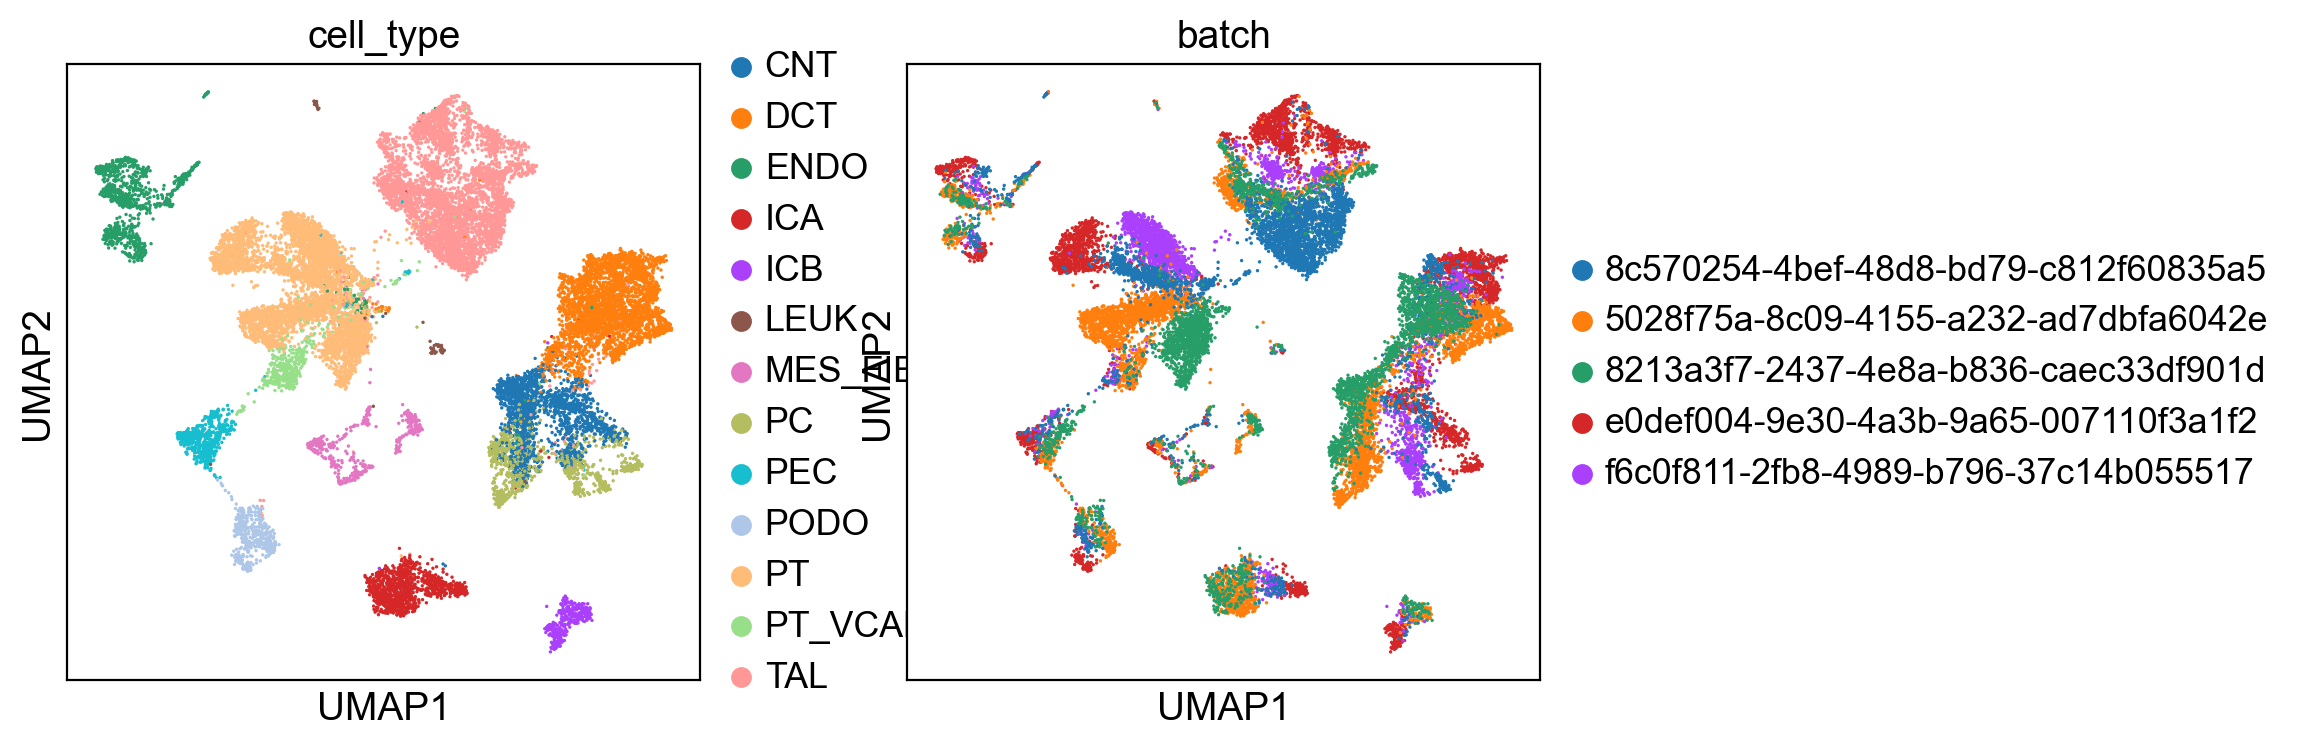

In [4]:
sc.pp.neighbors(rna, use_rep='X_pca')
sc.tl.umap(rna)
sc.pl.umap(rna, color=['cell_type', 'batch'])

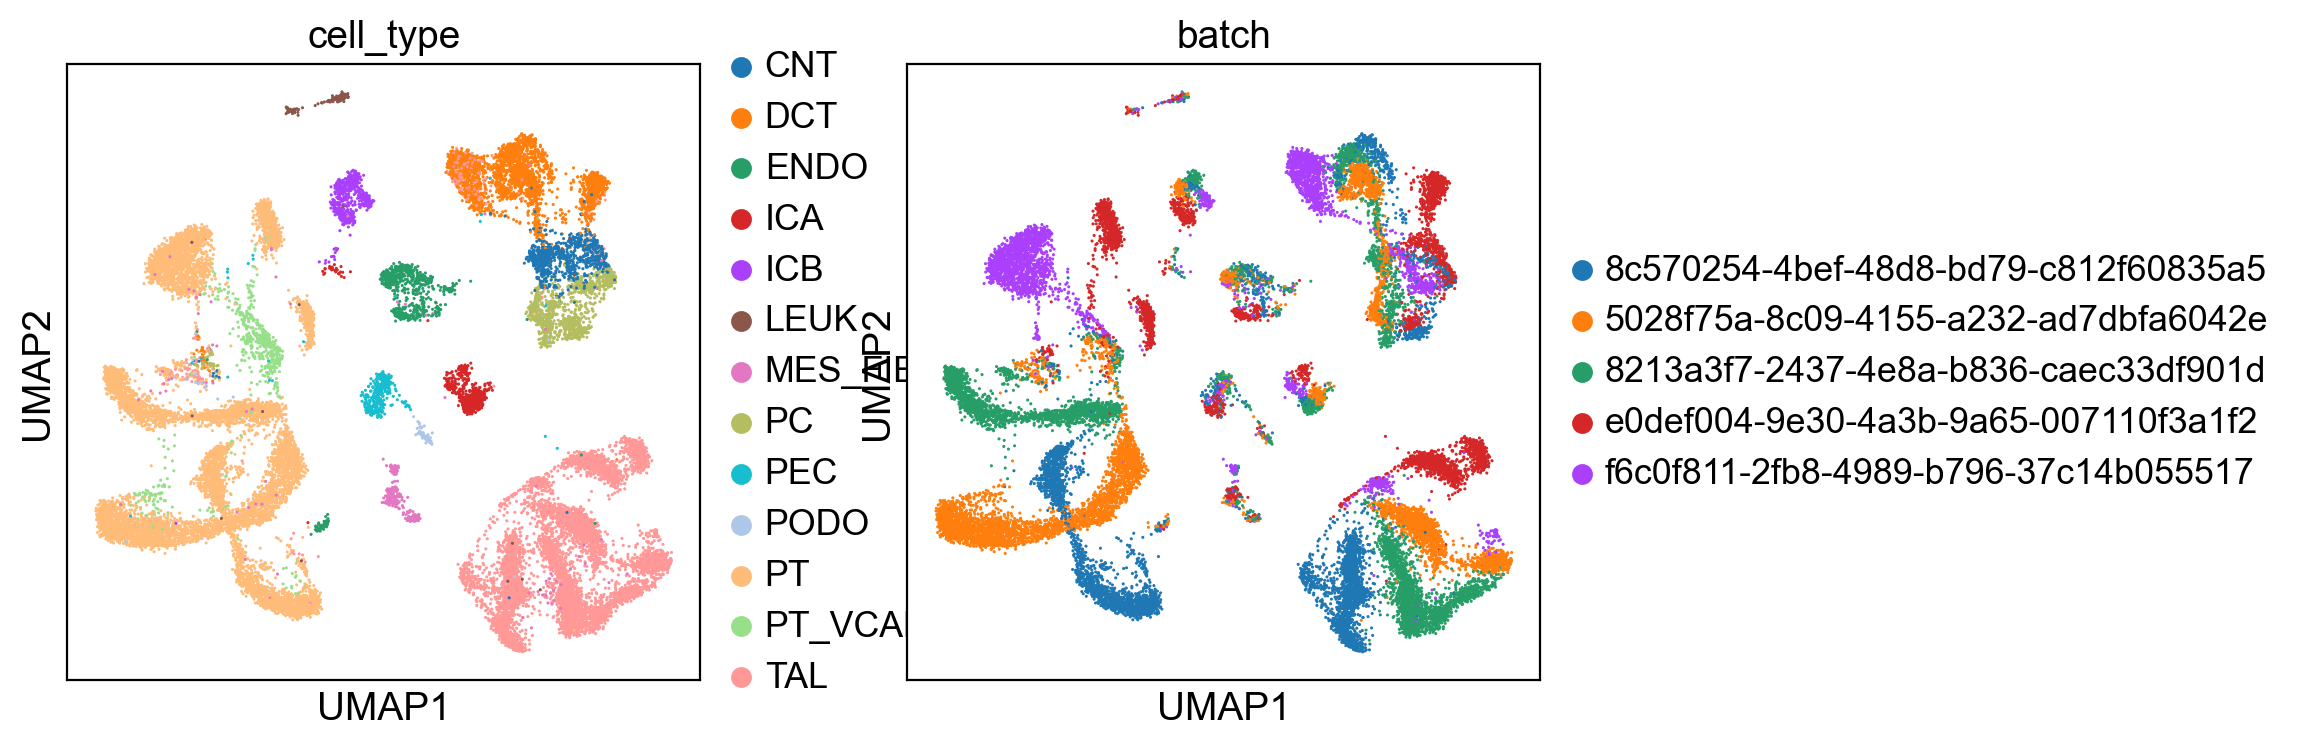

In [5]:
sc.pp.neighbors(atac_peak, use_rep='X_lsi')
sc.tl.umap(atac_peak)
sc.pl.umap(atac_peak, color=['cell_type', 'batch'])

Model

In [6]:
model = UniDISA.IntegrationModel(rna, atac_peak, input_key = ["X_pca", "X_lsi"], source_col='batch')

Stage1

In [7]:
model.train_stage1(training_steps=3000,
                       lambdaRecon=10.0,
                       lambdaLA=1.0,
                       lambdaDA=1.0)
model.get_latent_representation()

===== Stage 1: Initial Alignment =====
[Stage1 0] AE: 5.6643 | LA: 0.2594 | DA: 0.3035
[Stage1 500] AE: 1.1009 | LA: 0.0067 | DA: 0.6801
[Stage1 1000] AE: 1.1009 | LA: 0.0052 | DA: 0.5204
[Stage1 1500] AE: 1.0255 | LA: 0.0044 | DA: 0.4079
[Stage1 2000] AE: 0.9539 | LA: 0.0039 | DA: 0.3126
[Stage1 2500] AE: 0.9304 | LA: 0.0037 | DA: 0.3293
[Stage1 3000] AE: 0.9326 | LA: 0.0035 | DA: 0.2632
Total time: 0.61s
Latent shape: (44190, 10)


D:\anaconda3\envs\UniDISA\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


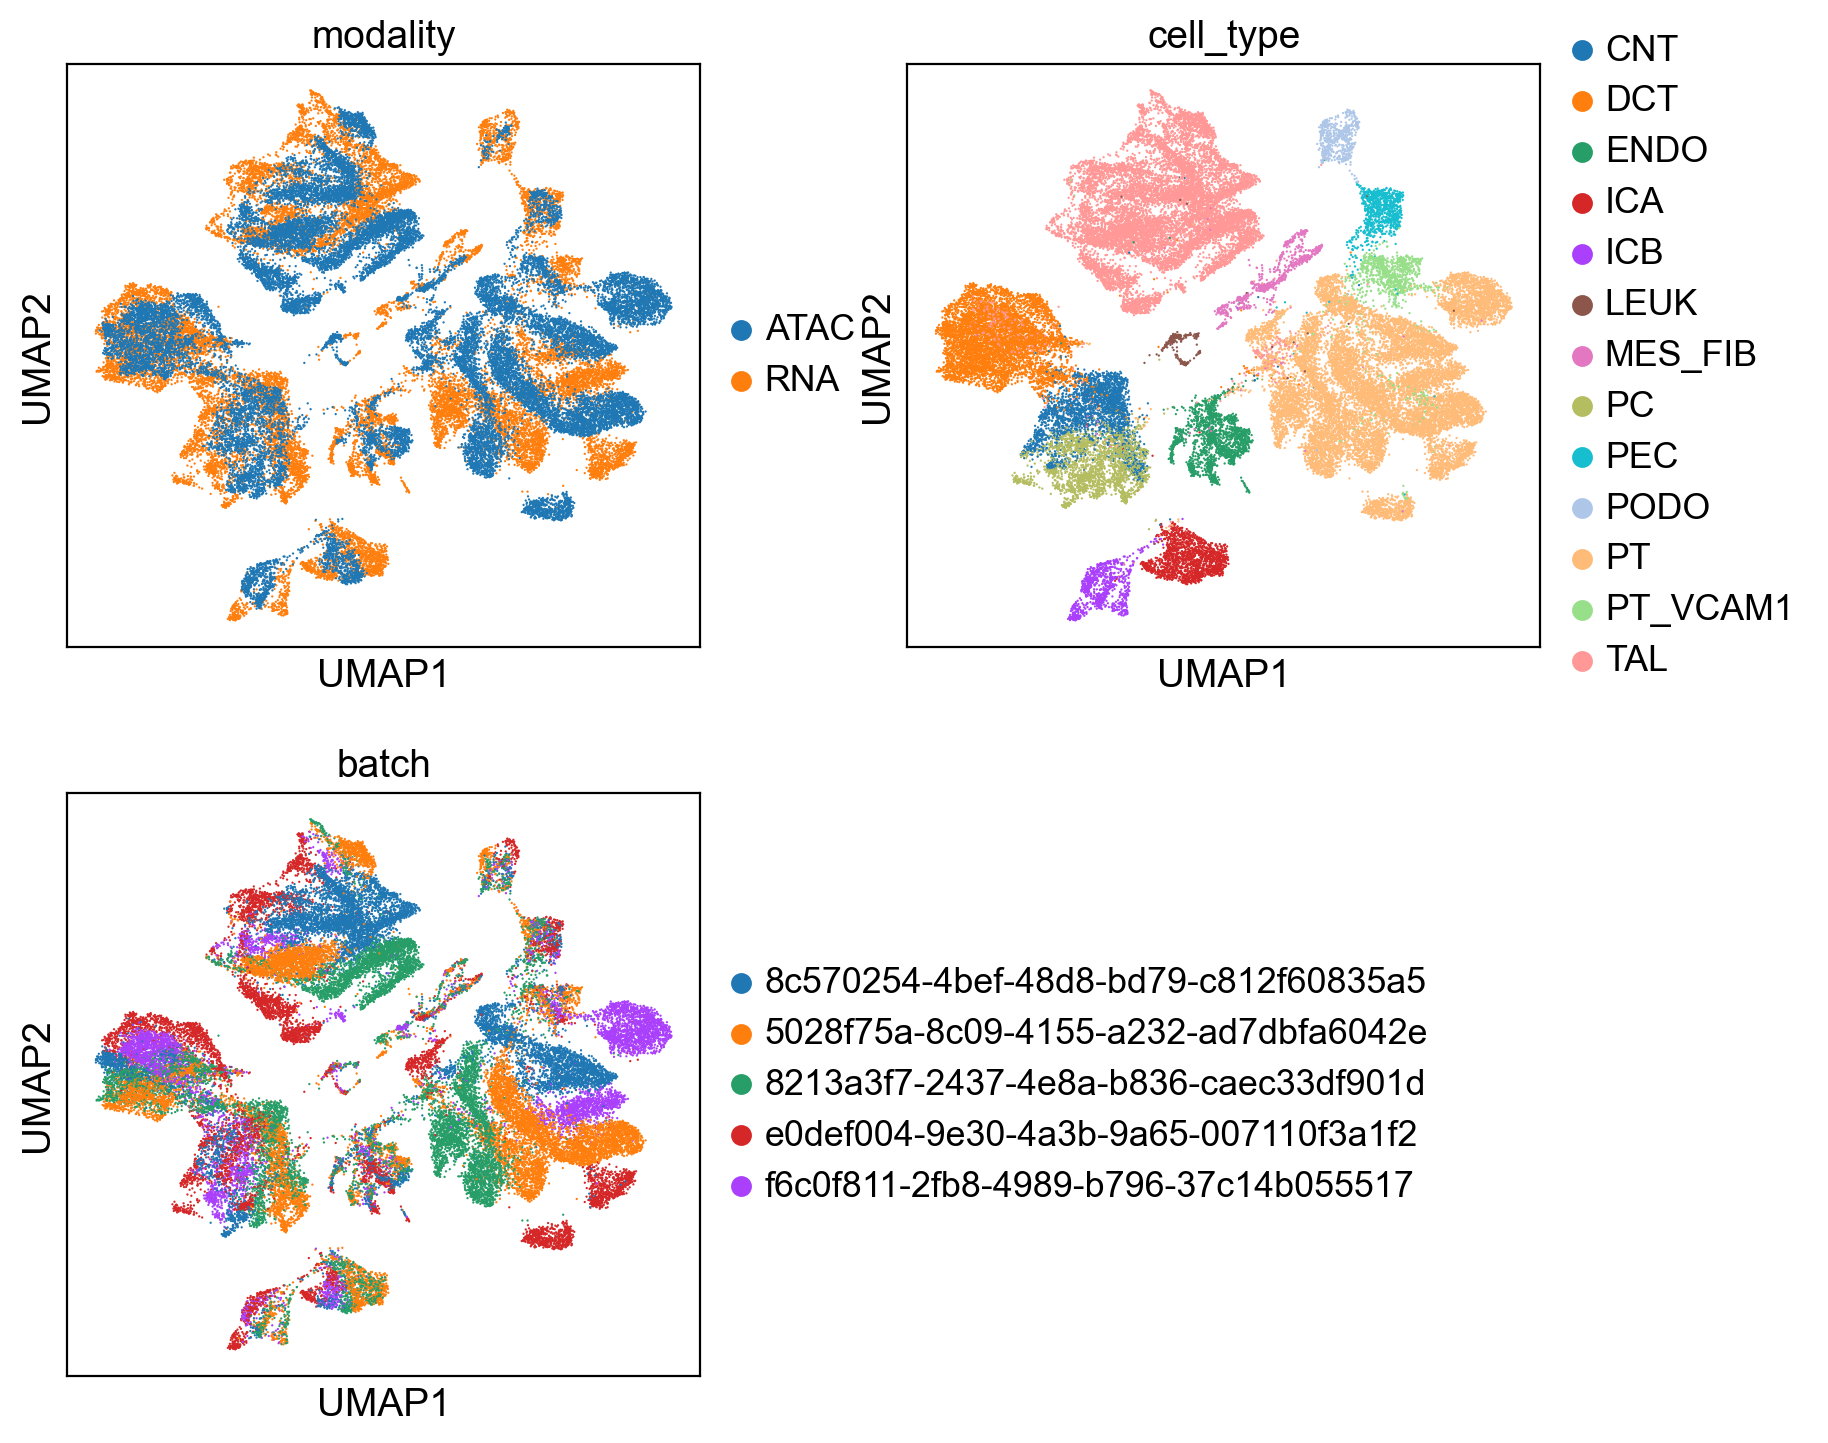

In [8]:
# Create integrated AnnData object
adata_integrated = ad.AnnData(
    X=model.latent,
    obs=pd.concat([rna.obs, atac_gas.obs])
)
adata_integrated.obs['modality'] = ['RNA'] * rna.shape[0] + ['ATAC'] * atac_gas.shape[0]

# Dimensionality reduction and visualization
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated)
sc.pl.umap(adata_integrated, color=['modality', 'cell_type', 'batch'], ncols=2)

Stage2

In [9]:
model.train_stage2(training_steps=3000,
                       lambdaRecon=10.0,
                       lambdaLA=1.0,
                       lambdaDA=1.0,
                       n_iters=1)
model.get_latent_representation()

===== Stage 2: Iterative Alignment 1/1 =====
[Stage2 0] AE: 5.5129 | LA: 0.3170 | DA: 0.3848
[Stage2 500] AE: 1.1817 | LA: 0.0104 | DA: 0.4682
[Stage2 1000] AE: 1.0140 | LA: 0.0078 | DA: 0.3172
[Stage2 1500] AE: 1.0036 | LA: 0.0069 | DA: 0.2594
[Stage2 2000] AE: 0.9789 | LA: 0.0060 | DA: 0.2401
[Stage2 2500] AE: 0.9870 | LA: 0.0067 | DA: 0.2449
[Stage2 3000] AE: 0.9164 | LA: 0.0056 | DA: 0.2300
Total time: 0.37s
Latent shape: (44190, 10)


D:\anaconda3\envs\UniDISA\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


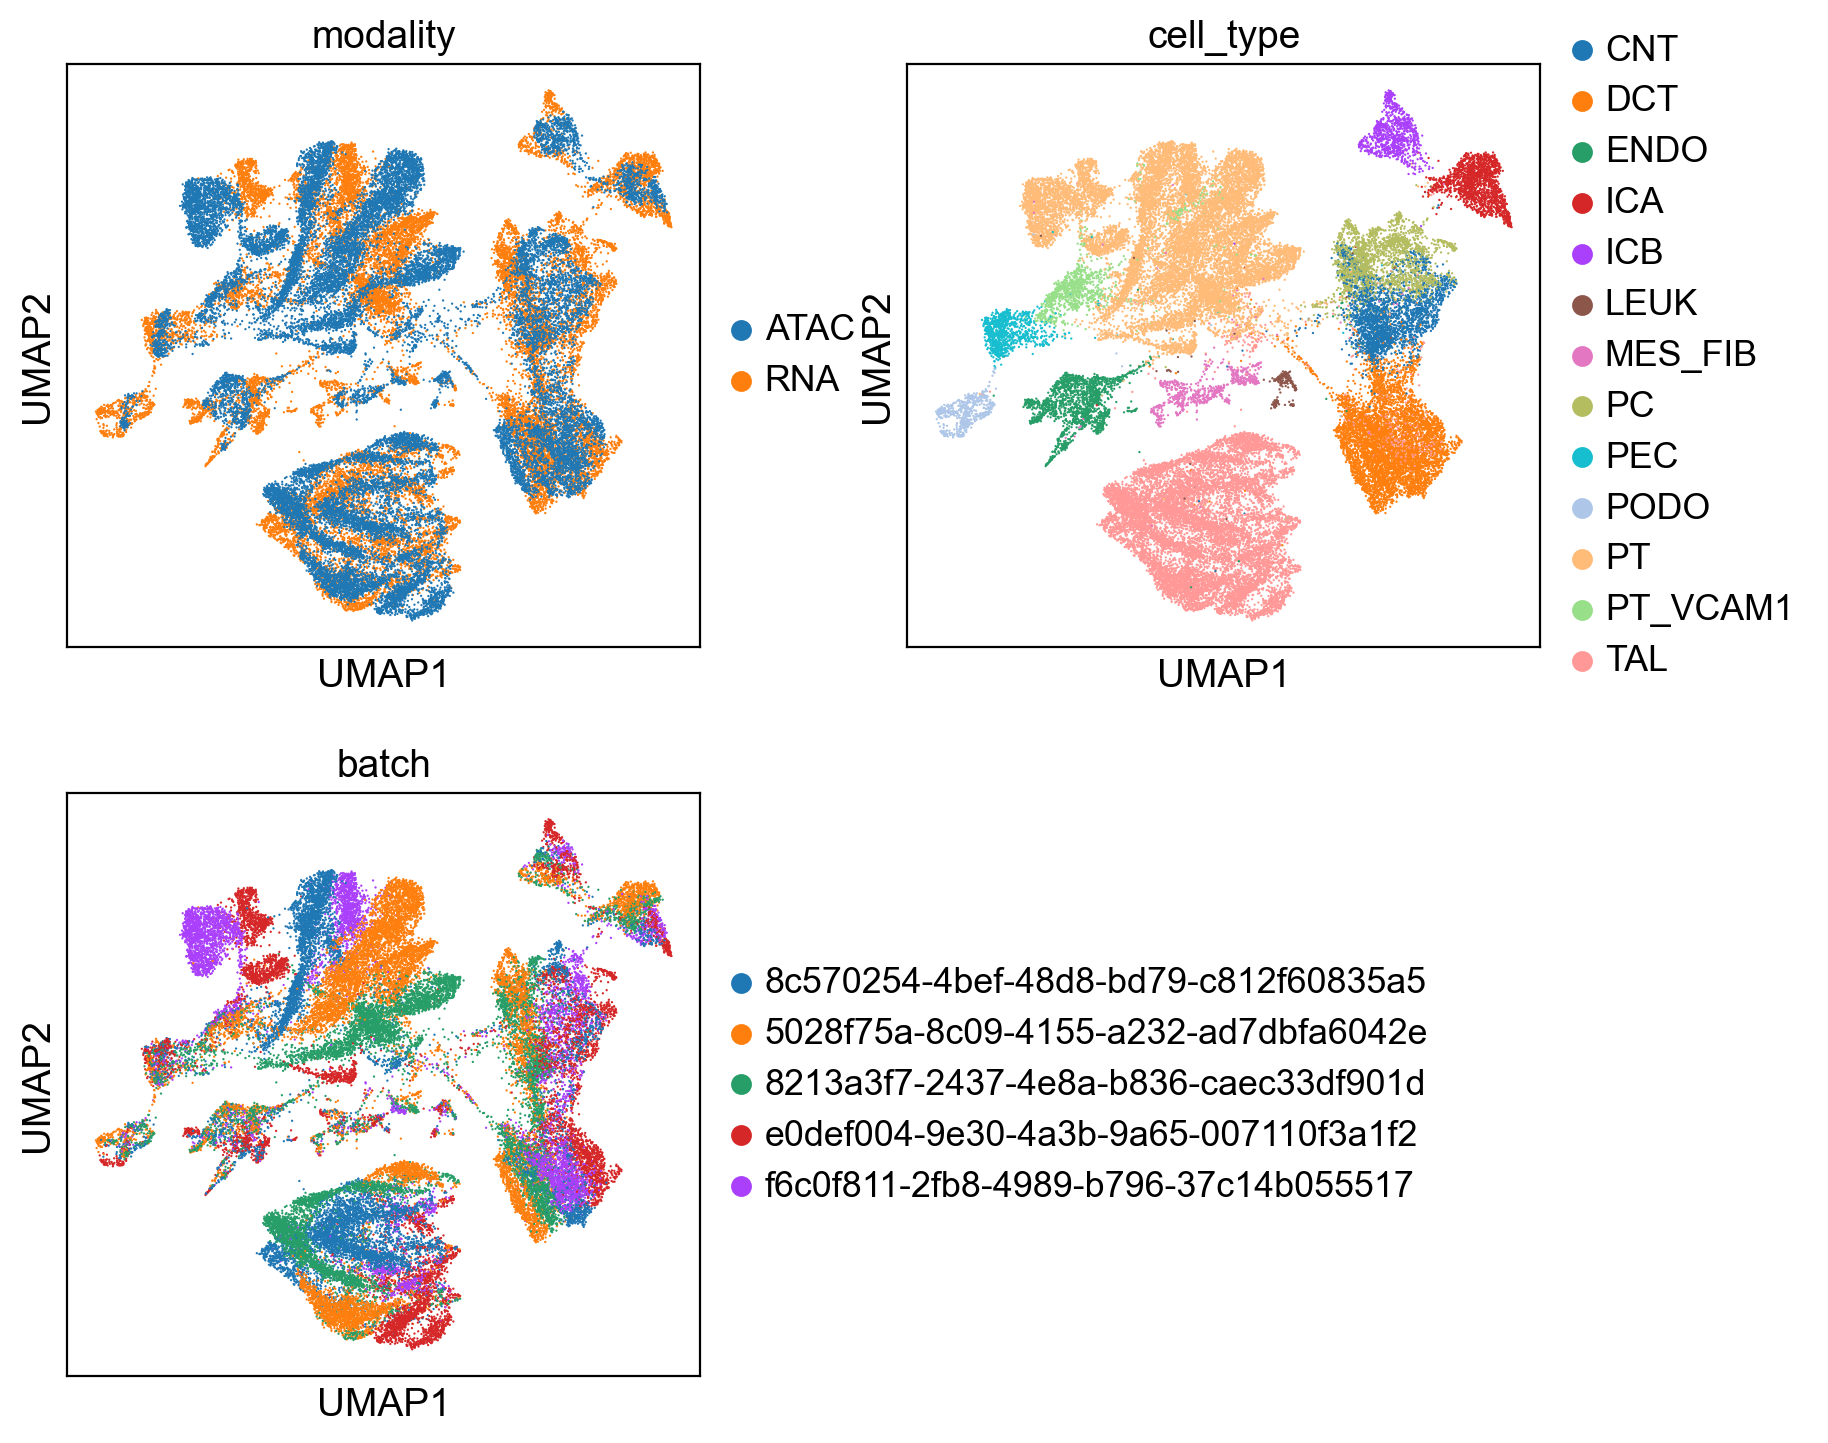

In [10]:
# Create integrated AnnData object
adata_integrated = ad.AnnData(
    X=model.latent,
    obs=pd.concat([rna.obs, atac_gas.obs])
)
adata_integrated.obs['modality'] = ['RNA'] * rna.shape[0] + ['ATAC'] * atac_gas.shape[0]

# Dimensionality reduction and visualization
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated)
sc.pl.umap(adata_integrated, color=['modality', 'cell_type', 'batch'], ncols=2)

Stage3

In [11]:
model.train_stage3(
    training_steps=10000,
    lambdaRecon=10.0,
    lambdaLA=1.0,
    lambdaDA=1.0,
    lambdamGAN=1.0,
    lambdabGAN=0.5,
    use_mGAN=True)
model.get_latent_representation()

===== Stage 3: Final Alignment =====
[Stage3 0] AE: 5.7752 | LA: 0.2602 | DA: 0.3033 | mGAN: -1.2073 | bGAN: -3.1203
[Stage3 1000] AE: 1.1058 | LA: 0.0223 | DA: 0.3430 | mGAN: -1.1595 | bGAN: -1.9056
[Stage3 2000] AE: 1.0541 | LA: 0.0253 | DA: 0.2570 | mGAN: -1.2618 | bGAN: -1.7833
[Stage3 3000] AE: 0.9953 | LA: 0.0218 | DA: 0.2546 | mGAN: -1.2373 | bGAN: -1.8566
[Stage3 4000] AE: 0.9688 | LA: 0.0217 | DA: 0.2141 | mGAN: -1.2209 | bGAN: -1.7880
[Stage3 5000] AE: 0.9542 | LA: 0.0193 | DA: 0.1944 | mGAN: -1.1967 | bGAN: -1.7472
[Stage3 6000] AE: 0.9551 | LA: 0.0201 | DA: 0.2003 | mGAN: -1.1841 | bGAN: -1.7890
[Stage3 7000] AE: 0.8928 | LA: 0.0165 | DA: 0.1677 | mGAN: -1.1909 | bGAN: -1.6951
[Stage3 8000] AE: 0.9207 | LA: 0.0160 | DA: 0.1644 | mGAN: -1.1908 | bGAN: -1.6951
[Stage3 9000] AE: 0.9482 | LA: 0.0183 | DA: 0.1733 | mGAN: -1.2279 | bGAN: -1.8237
[Stage3 10000] AE: 0.8669 | LA: 0.0160 | DA: 0.1501 | mGAN: -1.2178 | bGAN: -1.6728
Total time: 0.36s
Latent shape: (44190, 10)


D:\anaconda3\envs\UniDISA\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


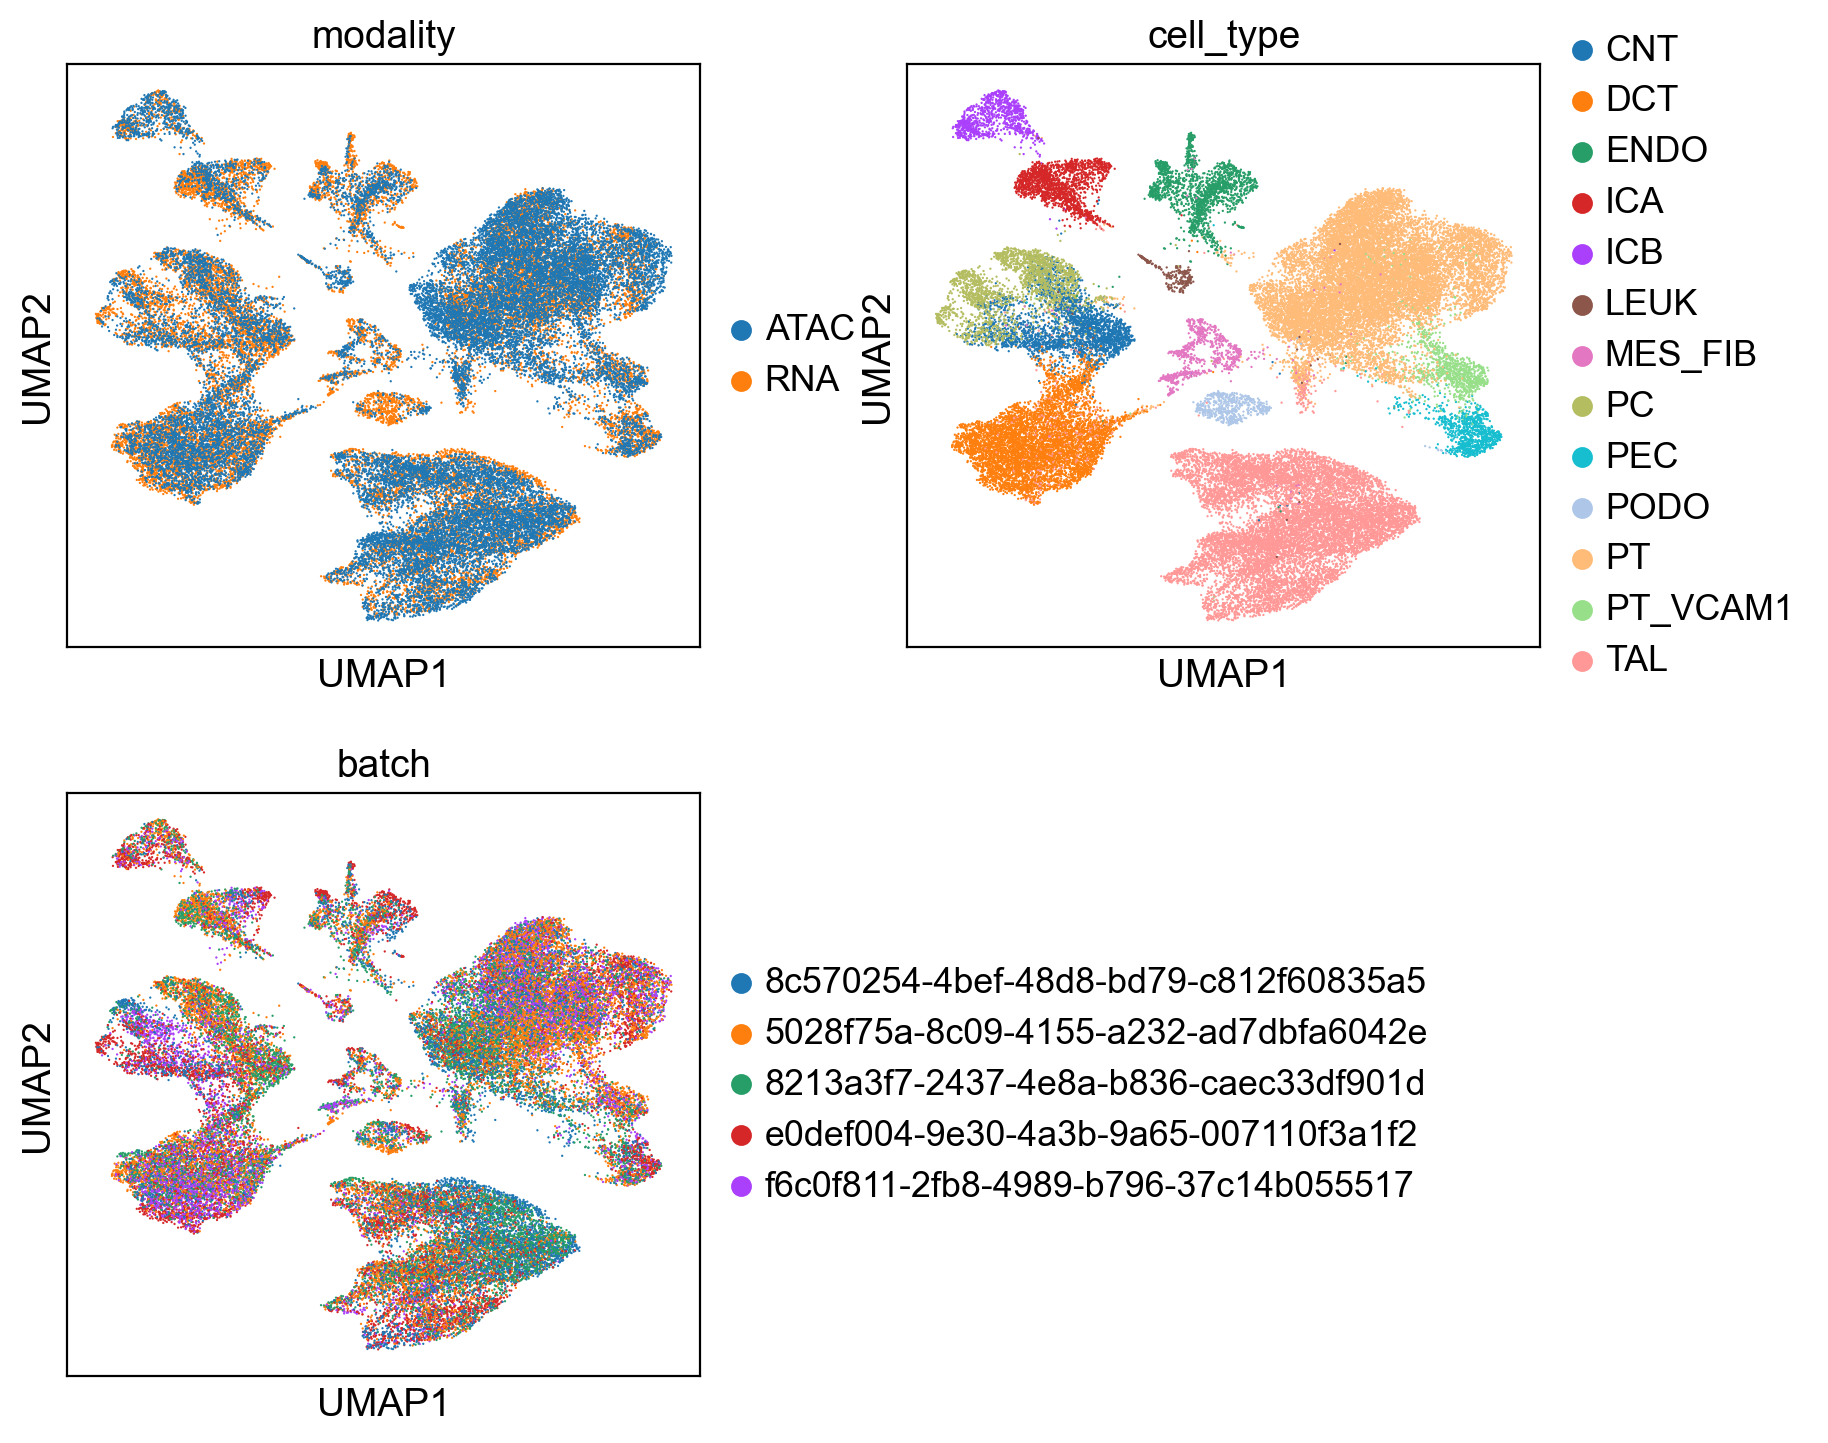

In [12]:
# Create integrated AnnData object
adata_integrated = ad.AnnData(
    X=model.latent,
    obs=pd.concat([rna.obs, atac_gas.obs])
)
adata_integrated.obs['modality'] = ['RNA'] * rna.shape[0] + ['ATAC'] * atac_gas.shape[0]

# Dimensionality reduction and visualization
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated)
sc.pl.umap(adata_integrated, color=['modality', 'cell_type', 'batch'], ncols=2)

In [13]:
acc, f1 = UniDISA.metrics.calculate_shared_type_transfer_metrics(adata_integrated, batch_key='modality', label_key='cell_type', embed="X_emb")

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
adata_integrated.obsm['X_emb'] = adata_integrated.X
%matplotlib inline
bm = Benchmarker(
    adata_integrated,
    batch_key="modality",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(silhouette_label=False),
    batch_correction_metrics=BatchCorrection(pcr_comparison=False),
    embedding_obsm_keys=["X_umap", "X_emb"],
    n_jobs=6,
)
bm.benchmark()

D:\anaconda3\envs\UniDISA\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
D:\anaconda3\envs\UniDISA\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
D:\anaconda3\envs\UniDISA\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Metrics:  50%|████████████████████                    | 5/10 [00:14<00:14,  2.91s/it, Batch correction: kbet_per_label]D:\anaconda3\envs\UniDISA\lib\site-packages\scib_metrics\metrics\_kbet.py:182: DeprecationWar

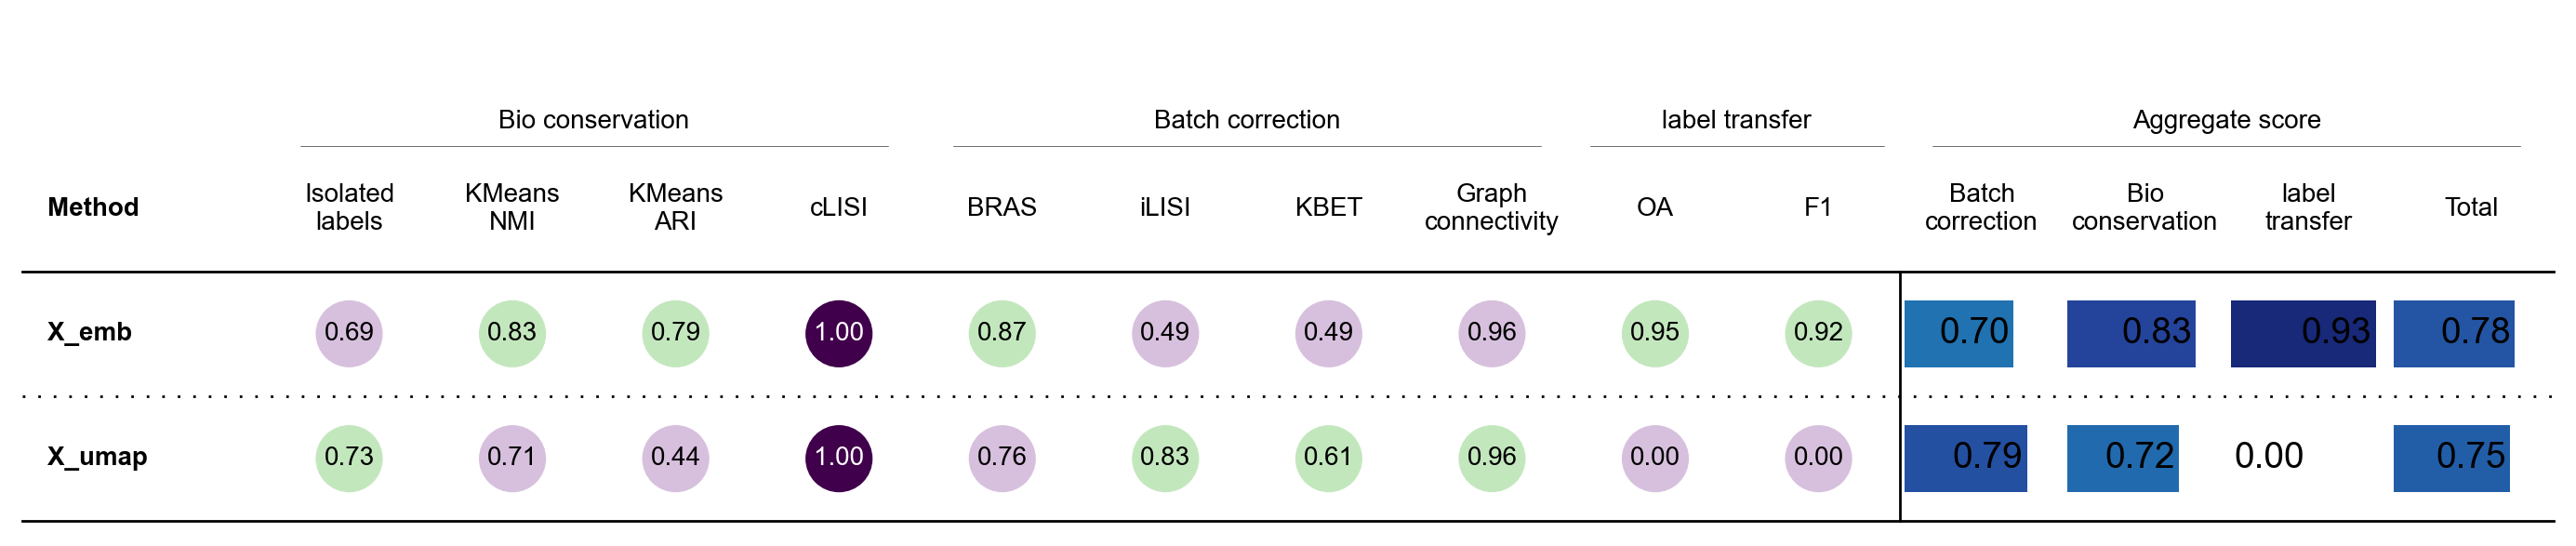

In [14]:
bm._results.loc['OA'] = {
    "X_umap": 0.0,
    "X_emb": acc,
    "Metric Type": "label transfer"
}
bm._results.loc['F1'] = {
    "X_umap": 0.0,
    "X_emb": f1,
    "Metric Type": "label transfer"
}
bm.plot_results_table(min_max_scale=False)